<a href="https://colab.research.google.com/github/didi-ardiansyah/credit_analysis/blob/main/credit_risk_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Credit Risk Scorecard Modeling
## Prediksi Gagal Bayar & Pembangunan Credit Scorecard

**Dataset:** Give Me Some Credit — Kaggle  
**Tools:** Python, scorecardpy, scikit-learn, pandas  
**Author:** Didi Ardiansyah  
**Metode:** Weight of Evidence (WoE) + Logistic Regression → Credit Scorecard

---

### Tujuan Proyek
Membangun model credit scoring berbasis **Credit Scorecard** yang dapat:
1. Memprediksi probabilitas nasabah gagal bayar dalam 2 tahun ke depan
2. Mengidentifikasi faktor-faktor risiko yang paling berpengaruh
3. Menghasilkan **skor kredit** yang bisa digunakan sebagai dasar keputusan approval

### Pertanyaan Bisnis
- Faktor apa yang paling berpengaruh terhadap risiko gagal bayar?
- Pada skor berapa sebaiknya bank menetapkan batas *cut-off* approval?
- Seberapa handal model ini diukur dari standar industri perbankan?


---
## Tahap 1 — Business Understanding

### Konteks Bisnis
Lembaga keuangan menghadapi risiko kredit setiap kali menyetujui pinjaman.  
Kesalahan prediksi memiliki dua jenis konsekuensi:

| Jenis Kesalahan | Deskripsi | Dampak Bisnis |
|---|---|---|
| **False Negative** | Nasabah buruk disetujui | Kerugian finansial langsung (NPL naik) |
| **False Positive** | Nasabah baik ditolak | Kehilangan pendapatan bunga |

**False Negative** diianggap lebih mahal,sehingga model credit scoring cenderung lebih konservatif (lebih banyak menolak).

### Definisi Target
- `SeriousDlqin2yrs = 1` → **BAD**: nasabah pernah telat bayar 90+ hari dalam 2 tahun
- `SeriousDlqin2yrs = 0` → **GOOD**: nasabah tidak pernah telat bayar serius


In [77]:
# ── Import Library ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
!pip install scorecardpy
import scorecardpy as sc
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Pengaturan tampilan
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')


---
## Tahap 2 — Data Understanding & EDA

Memahami struktur data, kualitas data, dan distribusi setiap variabel sebelum masuk ke proses pemodelan.


In [78]:
# ── Load Data ───────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive/')
df = pd.read_csv('cs-training.csv', index_col=0)

print(f"Dimensi data: {df.shape[0]:,} baris × {df.shape[1]} kolom")
print()
df.head()


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Dimensi data: 150,000 baris × 11 kolom



,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.7661,45,2,0.8030,9120.0000,13,0,6,0,2.0000
2,0,0.9572,40,0,0.1219,2600.0000,4,0,0,0,1.0000
3,0,0.6582,38,1,0.0851,3042.0000,2,1,0,0,0.0000
4,0,0.2338,30,0,0.0360,3300.0000,5,0,0,0,0.0000
5,0,0.9072,49,1,0.0249,63588.0000,7,0,1,0,0.0000


In [79]:
# ── Informasi Dasar Dataset ─────────────────────────────────────────────
print("INFORMASI TIPE DATA & MISSING VALUES")

info_df = pd.DataFrame({
    'Tipe Data'    : df.dtypes,
    'Nilai Kosong' : df.isnull().sum(),
    'Persen Kosong': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info_df.to_string())


INFORMASI TIPE DATA & MISSING VALUES
                                     Tipe Data  Nilai Kosong  Persen Kosong
SeriousDlqin2yrs                         int64             0         0.0000
RevolvingUtilizationOfUnsecuredLines   float64             0         0.0000
age                                      int64             0         0.0000
NumberOfTime30-59DaysPastDueNotWorse     int64             0         0.0000
DebtRatio                              float64             0         0.0000
MonthlyIncome                          float64         29731        19.8200
NumberOfOpenCreditLinesAndLoans          int64             0         0.0000
NumberOfTimes90DaysLate                  int64             0         0.0000
NumberRealEstateLoansOrLines             int64             0         0.0000
NumberOfTime60-89DaysPastDueNotWorse     int64             0         0.0000
NumberOfDependents                     float64          3924         2.6200


In [80]:
# ── Statistik Deskriptif ─────────────────────────────────────────────────
print("STATISTIK DESKRIPTIF")
df.describe().T.round(2)


STATISTIK DESKRIPTIF


,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0000,0.0700,0.2500,0.0000,0.0000,0.0000,0.0000,1.0000
RevolvingUtilizationOfUnsecuredLines,150000.0000,6.0500,249.7600,0.0000,0.0300,0.1500,0.5600,50708.0000
age,150000.0000,52.3000,14.7700,0.0000,41.0000,52.0000,63.0000,109.0000
NumberOfTime30-59DaysPastDueNotWorse,150000.0000,0.4200,4.1900,0.0000,0.0000,0.0000,0.0000,98.0000
DebtRatio,150000.0000,353.0100,2037.8200,0.0000,0.1800,0.3700,0.8700,329664.0000
MonthlyIncome,120269.0000,6670.2200,14384.6700,0.0000,3400.0000,5400.0000,8249.0000,3008750.0000
NumberOfOpenCreditLinesAndLoans,150000.0000,8.4500,5.1500,0.0000,5.0000,8.0000,11.0000,58.0000
NumberOfTimes90DaysLate,150000.0000,0.2700,4.1700,0.0000,0.0000,0.0000,0.0000,98.0000
NumberRealEstateLoansOrLines,150000.0000,1.0200,1.1300,0.0000,0.0000,1.0000,2.0000,54.0000
NumberOfTime60-89DaysPastDueNotWorse,150000.0000,0.2400,4.1600,0.0000,0.0000,0.0000,0.0000,98.0000


DISTRIBUSI TARGET VARIABEL
  GOOD (tidak gagal bayar) :  139,974  (93.32%)
  BAD  (gagal bayar)       :   10,026  (6.68%)
  Total                    :  150,000

➡️  Bad Rate keseluruhan: 6.68%

Data tidak seimbang (imbalanced)


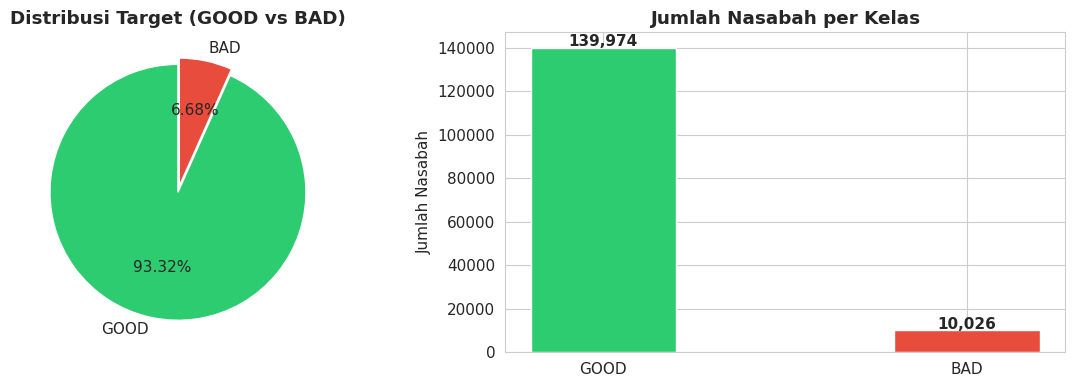

In [81]:
# ── Analisis Target: Bad Rate ────────────────────────────────────────────
target = 'SeriousDlqin2yrs'
bad_rate = df[target].mean() * 100
good_count = (df[target] == 0).sum()
bad_count  = (df[target] == 1).sum()

print("DISTRIBUSI TARGET VARIABEL")
print(f"  GOOD (tidak gagal bayar) : {good_count:>8,}  ({100 - bad_rate:.2f}%)")
print(f"  BAD  (gagal bayar)       : {bad_count:>8,}  ({bad_rate:.2f}%)")
print(f"  Total                    : {len(df):>8,}")
print()
print(f"➡️  Bad Rate keseluruhan: {bad_rate:.2f}%")
print()
if bad_rate < 20:
    print("Data tidak seimbang (imbalanced)")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
axes[0].pie([good_count, bad_count],
            labels=['GOOD', 'BAD'],
            autopct='%1.2f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90,
            explode=(0, 0.05))
axes[0].set_title('Distribusi Target (GOOD vs BAD)', fontweight='bold')

# Bar chart
axes[1].bar(['GOOD', 'BAD'], [good_count, bad_count],
            color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.4)
axes[1].set_title('Jumlah Nasabah per Kelas', fontweight='bold')
axes[1].set_ylabel('Jumlah Nasabah')
for i, v in enumerate([good_count, bad_count]):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('01_distribusi_target.png', dpi=150, bbox_inches='tight')
plt.show()


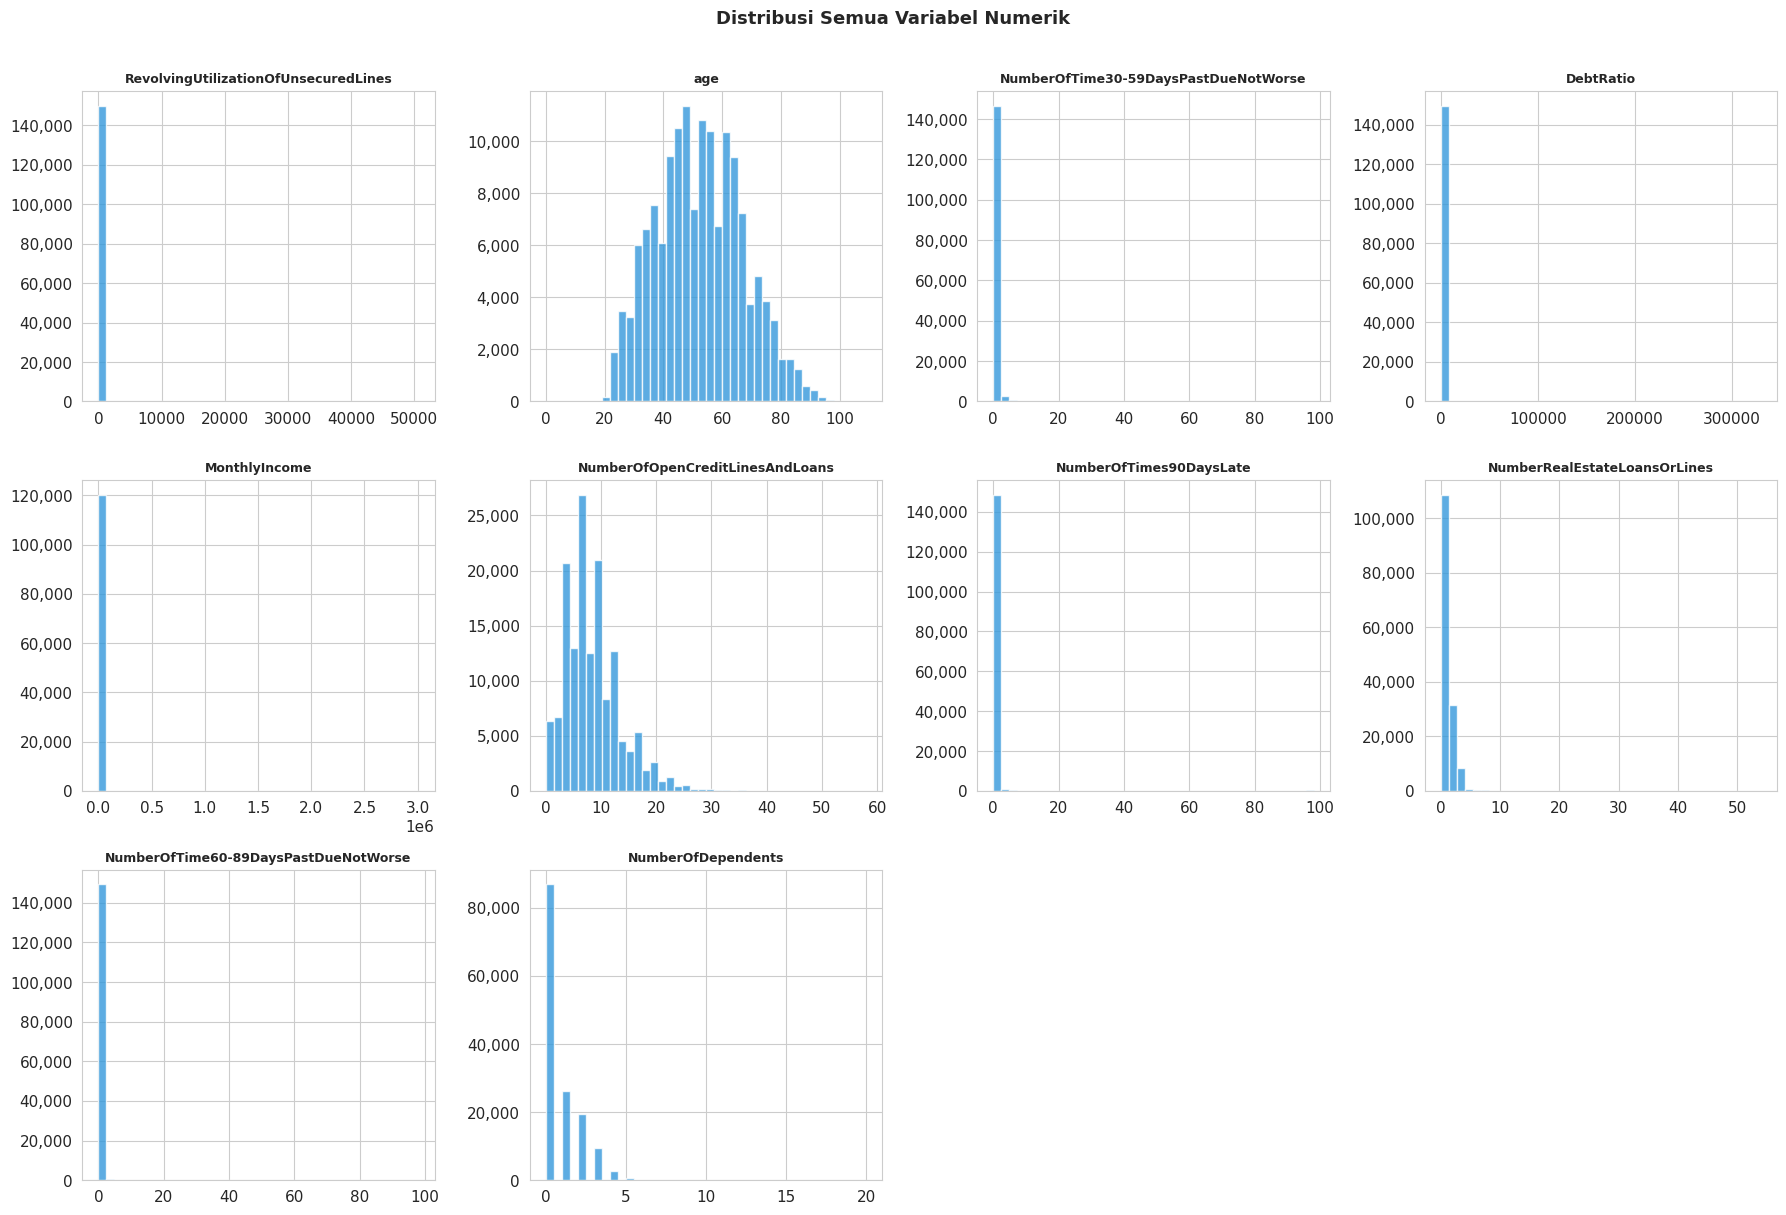

In [82]:
# ── Distribusi Variabel Numerik ──────────────────────────────────────────
fitur_num = [col for col in df.columns if col != target]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(fitur_num):
    axes[i].hist(df[col].dropna(), bins=40,
                 color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Sembunyikan subplot kosong jika ada
for j in range(len(fitur_num), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Semua Variabel Numerik', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_distribusi_variabel.png', dpi=150, bbox_inches='tight')
plt.show()


In [83]:
# ── Deteksi Outlier dengan IQR ───────────────────────────────────────────
print("DETEKSI OUTLIER")

outlier_summary = []
for col in fitur_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas  = Q3 + 1.5 * IQR
    n_outlier   = ((df[col] < batas_bawah) | (df[col] > batas_atas)).sum()
    outlier_summary.append({
        'Variabel' : col,
        'Q1' : round(Q1, 2),
        'Q3' : round(Q3, 2),
        'Batas Bawah' : round(batas_bawah, 2),
        'Batas Atas' : round(batas_atas, 2),
        'Jumlah Outlier': n_outlier,
        'Persen Outlier': f"{n_outlier/len(df)*100:.2f}%"})

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))


DETEKSI OUTLIER
                            Variabel        Q1        Q3  Batas Bawah  Batas Atas  Jumlah Outlier Persen Outlier
RevolvingUtilizationOfUnsecuredLines    0.0300    0.5600      -0.7600      1.3500             763          0.51%
                                 age   41.0000   63.0000       8.0000     96.0000              46          0.03%
NumberOfTime30-59DaysPastDueNotWorse    0.0000    0.0000       0.0000      0.0000           23982         15.99%
                           DebtRatio    0.1800    0.8700      -0.8600      1.9100           31311         20.87%
                       MonthlyIncome 3400.0000 8249.0000   -3873.5000  15522.5000            4879          3.25%
     NumberOfOpenCreditLinesAndLoans    5.0000   11.0000      -4.0000     20.0000            3980          2.65%
             NumberOfTimes90DaysLate    0.0000    0.0000       0.0000      0.0000            8338          5.56%
        NumberRealEstateLoansOrLines    0.0000    2.0000      -3.0000      5.000

---
## Tahap 3 — Data Preprocessing

Menangani data tidak bersih agar siap masuk ke proses pemodelan:
- **Missing values** → imputasi dengan median
- **Outlier** → capping (winsorizing) pada persentil 1% dan 99%
- **Train/Test split** → 70% training, 30% testing


In [84]:
# ── Rename Kolom (opsional, lebih mudah dibaca) ──────────────────────────
rename_map = {
    'SeriousDlqin2yrs' : 'target',
    'RevolvingUtilizationOfUnsecuredLines' : 'util_rate',
    'age' : 'usia',
    'NumberOfTime30-59DaysPastDueNotWorse' : 'telat_30_59',
    'DebtRatio' : 'debt_ratio',
    'MonthlyIncome' : 'pendapatan',
    'NumberOfOpenCreditLinesAndLoans' : 'jml_kredit',
    'NumberOfTimes90DaysLate' : 'telat_90',
    'NumberRealEstateLoansOrLines' : 'kredit_properti',
    'NumberOfTime60-89DaysPastDueNotWorse' : 'telat_60_89',
    'NumberOfDependents' : 'tanggungan'}
df = df.rename(columns=rename_map)
target = 'target'
print(list(df.columns))


['target', 'util_rate', 'usia', 'telat_30_59', 'debt_ratio', 'pendapatan', 'jml_kredit', 'telat_90', 'kredit_properti', 'telat_60_89', 'tanggungan']


In [85]:
# ── Imputasi Missing Values ───────────────────────────────────────────────
print("Missing values SEBELUM imputasi:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()

# Imputasi dengan median
for col in df.columns:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"{col}: diisi dengan median = {median_val:.2f}")

print()
print("Missing values SETELAH imputasi:")
print(df.isnull().sum()[df.isnull().sum() > 0])
if df.isnull().sum().sum() == 0:
    print("Tidak ada missing values tersisa")


Missing values SEBELUM imputasi:
pendapatan    29731
tanggungan     3924
dtype: int64

pendapatan: diisi dengan median = 5400.00
tanggungan: diisi dengan median = 0.00

Missing values SETELAH imputasi:
Series([], dtype: int64)
Tidak ada missing values tersisa


In [86]:
# ── Capping Outlier (Winsorizing) ────────────────────────────────────────
# Batasi nilai ekstrem pada persentil 1% dan 99%
fitur_num = [col for col in df.columns if col != target]

for col in fitur_num:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=p01, upper=p99)

print("Statistik setelah capping:")
df[fitur_num].describe().T[['min', 'max', 'mean', '50%']].round(2)


Statistik setelah capping:


,min,max,mean,50%
util_rate,0.0000,1.0900,0.3200,0.1500
usia,24.0000,87.0000,52.2800,52.0000
telat_30_59,0.0000,4.0000,0.2500,0.0000
debt_ratio,0.0000,4979.0400,316.5500,0.3700
pendapatan,0.0000,23000.0000,6142.4500,5400.0000
jml_kredit,0.0000,24.0000,8.4000,8.0000
telat_90,0.0000,3.0000,0.0900,0.0000
kredit_properti,0.0000,4.0000,0.9900,1.0000
telat_60_89,0.0000,2.0000,0.0600,0.0000
tanggungan,0.0000,4.0000,0.7300,0.0000


In [87]:
# ── Train / Test Split ───────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    df,
    test_size = 0.3,
    random_state = 42,
    stratify = df[target]
)

print(f"Data Training : {len(train):>7,} baris  |  Bad Rate: {train[target].mean()*100:.2f}%")
print(f"Data Testing  : {len(test):>7,} baris  |  Bad Rate: {test[target].mean()*100:.2f}%")


Data Training : 105,000 baris  |  Bad Rate: 6.68%
Data Testing  :  45,000 baris  |  Bad Rate: 6.68%


---
## Tahap 4 — Weight of Evidence (WoE) & Information Value (IV)

**WoE dan IV** adalah teknik standar industri perbankan untuk:
- Mengubah variabel numerik menjadi representasi yang optimal untuk Logistic Regression
- Mengukur kekuatan prediktif setiap variabel terhadap target

### Rumus WoE
```
WoE(bin) = ln( % GOOD dalam bin / % BAD dalam bin )
```

### Interpretasi Information Value (IV)
| Nilai IV | Kekuatan Prediktif |
|---|---|
| < 0.02 | Tidak prediktif |
| 0.02 – 0.1 | Lemah |
| 0.1 – 0.3 | Medium |
| > 0.3 | Kuat |
| > 0.5 | Terlalu kuat |


In [88]:
# ── Binning & Kalkulasi WoE / IV ─────────────────────────────────────────
import scorecardpy as sc

# Automatic binning menggunakan scorecardpy
bins = sc.woebin(train, y=target, method='tree')

print("Binning selesai untuk semua variabel.")
print(f"Total variabel yang dibin: {len(bins)}")


[INFO] creating woe binning ...
Binning on 105000 rows and 11 columns in 00:00:20
Binning selesai untuk semua variabel.
Total variabel yang dibin: 10


In [89]:
# ── Tabel Information Value ──────────────────────────────────────────────
# Kumpulkan IV per variabel
iv_list = []
for var, bin_df in bins.items():
    iv_val = bin_df['total_iv'].iloc[0]
    iv_list.append({'Variabel': var, 'IV': round(iv_val, 4)})

iv_df = (pd.DataFrame(iv_list)
           .sort_values('IV', ascending=False)
           .reset_index(drop=True))

# Tambahkan label interpretasi
def label_iv(iv):
    if iv < 0.02:  return 'Tidak Prediktif'
    elif iv < 0.1: return 'Lemah'
    elif iv < 0.3: return 'Medium'
    elif iv < 0.5: return 'Kuat'
    else: return 'Sangat Kuat'

iv_df['Interpretasi'] = iv_df['IV'].apply(label_iv)

print("INFORMATION VALUE PER VARIABEL")
print(iv_df.to_string(index=False))


INFORMATION VALUE PER VARIABEL
       Variabel     IV Interpretasi
      util_rate 1.0801  Sangat Kuat
       telat_90 0.8510  Sangat Kuat
    telat_30_59 0.7245  Sangat Kuat
    telat_60_89 0.5752  Sangat Kuat
           usia 0.2339       Medium
     jml_kredit 0.0764        Lemah
     debt_ratio 0.0749        Lemah
     pendapatan 0.0681        Lemah
kredit_properti 0.0569        Lemah
     tanggungan 0.0327        Lemah


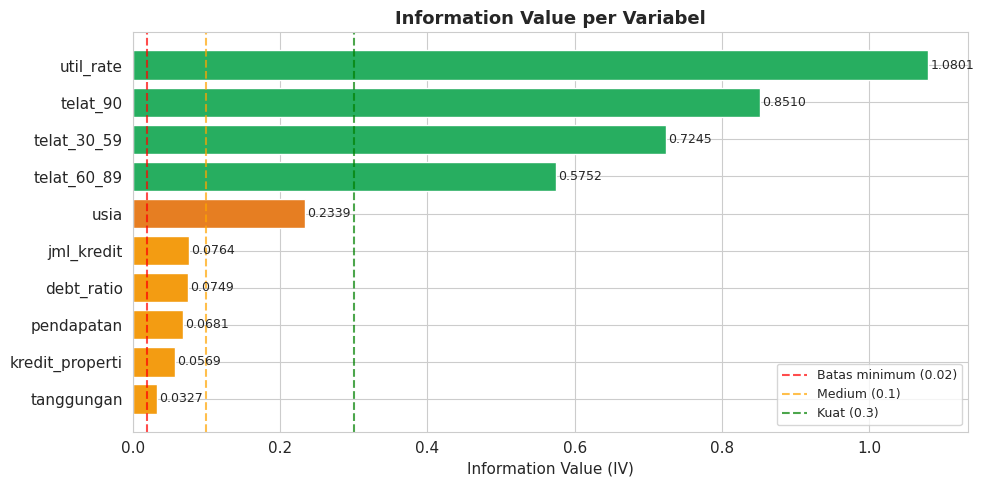

In [90]:
# ── Visualisasi IV ────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if iv < 0.02 else '#f39c12' if iv < 0.1
          else '#e67e22' if iv < 0.3 else '#27ae60'
          for iv in iv_df['IV']]

bars = plt.barh(iv_df['Variabel'][::-1], iv_df['IV'][::-1],
                color=colors[::-1], edgecolor='white')
plt.axvline(x=0.02, color='red', linestyle='--', alpha=0.7, label='Batas minimum (0.02)')
plt.axvline(x=0.1,  color='orange', linestyle='--', alpha=0.7, label='Medium (0.1)')
plt.axvline(x=0.3,  color='green',  linestyle='--', alpha=0.7, label='Kuat (0.3)')

for bar, val in zip(bars[::-1], iv_df['IV']):
    plt.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.xlabel('Information Value (IV)')
plt.title('Information Value per Variabel', fontweight='bold', fontsize=13)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('03_information_value.png', dpi=150, bbox_inches='tight')
plt.show()


In [91]:
# ── Seleksi Variabel Berdasarkan IV ─────────────────────────────────────
var_selected = iv_df[iv_df['IV'] >= 0.02]['Variabel'].tolist()

print(f"Variabel LOLOS seleksi IV (>= 0.02): {len(var_selected)}")
for v in var_selected:
    iv_val = iv_df[iv_df['Variabel'] == v]['IV'].values[0]
    print(f"{v:<30} IV = {iv_val:.4f}")

print()
var_dropped = iv_df[iv_df['IV'] < 0.02]['Variabel'].tolist()
if var_dropped:
    print(f"Variabel DIBUANG (IV < 0.02): {len(var_dropped)}")
    for v in var_dropped:
        iv_val = iv_df[iv_df['Variabel'] == v]['IV'].values[0]
        print(f"  ❌ {v:<30} IV = {iv_val:.4f}")
else:
    print("Tidak ada variabel yang dibuang.")


Variabel LOLOS seleksi IV (>= 0.02): 10
util_rate                      IV = 1.0801
telat_90                       IV = 0.8510
telat_30_59                    IV = 0.7245
telat_60_89                    IV = 0.5752
usia                           IV = 0.2339
jml_kredit                     IV = 0.0764
debt_ratio                     IV = 0.0749
pendapatan                     IV = 0.0681
kredit_properti                IV = 0.0569
tanggungan                     IV = 0.0327

Tidak ada variabel yang dibuang.


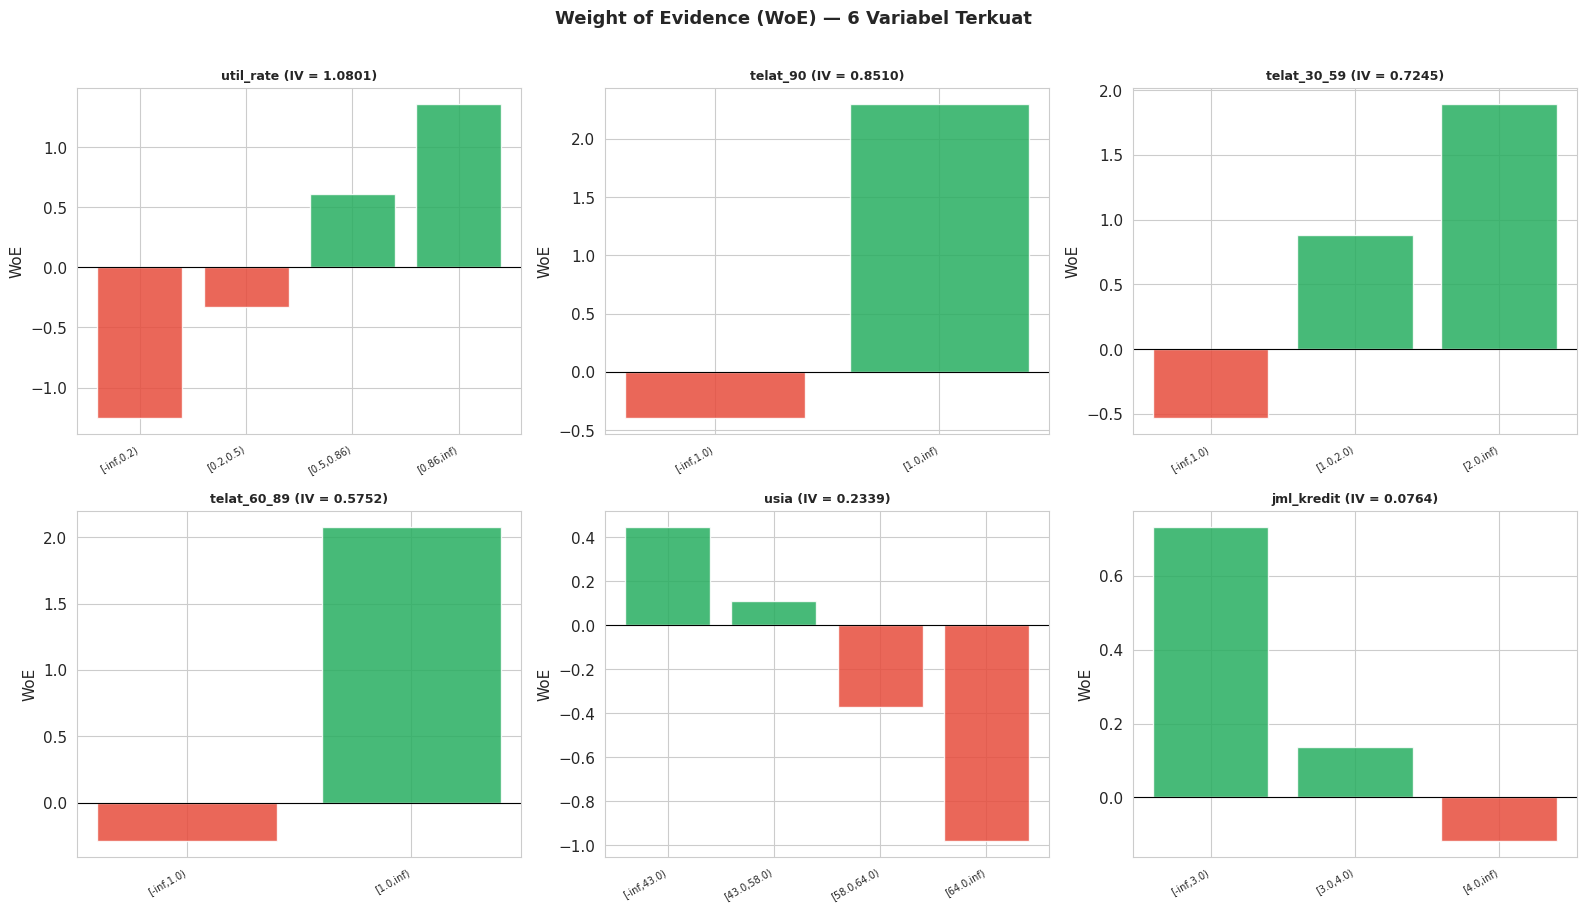

In [92]:
# ── Visualisasi WoE per Variabel ─────────────────────────────────────────
# Tampilkan WoE plot untuk variabel dengan IV terkuat
top_vars = iv_df.head(6)['Variabel'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(top_vars):
    bin_df = bins[var].copy()
    bin_labels = bin_df['bin'].astype(str)
    woe_vals   = bin_df['woe']

    bar_colors = ['#e74c3c' if w < 0 else '#27ae60' for w in woe_vals]
    axes[i].bar(range(len(woe_vals)), woe_vals, color=bar_colors,
                edgecolor='white', alpha=0.85)
    axes[i].axhline(y=0, color='black', linewidth=0.8)
    axes[i].set_xticks(range(len(bin_labels)))
    axes[i].set_xticklabels(bin_labels, rotation=30, ha='right', fontsize=7)
    axes[i].set_title(f'{var} (IV = {iv_df[iv_df["Variabel"]==var]["IV"].values[0]:.4f})',
                      fontsize=9, fontweight='bold')
    axes[i].set_ylabel('WoE')

plt.suptitle('Weight of Evidence (WoE) — 6 Variabel Terkuat',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('04_woe_plot.png', dpi=150, bbox_inches='tight')
plt.show()


In [93]:
# ── Transformasi WoE ke Dataset ──────────────────────────────────────────
# Filter bins hanya untuk variabel yang lolos seleksi
bins_selected = {k: v for k, v in bins.items() if k in var_selected}

# Transformasi nilai asli → nilai WoE
train_woe = sc.woebin_ply(train, bins_selected)
test_woe  = sc.woebin_ply(test,  bins_selected)

# Kolom WoE memiliki suffix '_woe'
woe_cols = [col for col in train_woe.columns if col.endswith('_woe')]

print("data setelah transformasi WoE:")
train_woe[woe_cols[:5]].head()

[INFO] converting into woe values ...
[INFO] converting into woe values ...
data setelah transformasi WoE:


,pendapatan_woe,debt_ratio_woe,telat_90_woe,kredit_properti_woe,usia_woe
138986,-0.1167,-0.1337,-0.3959,0.2347,0.1110
63965,0.3450,0.1006,-0.3959,-0.2619,0.4494
46078,0.3450,0.3824,-0.3959,-0.2619,0.4494
83031,-0.3798,-0.1337,-0.3959,0.2812,0.1110
11185,-0.1167,0.1006,-0.3959,0.2812,0.4494


---
## Tahap 5 — Pemodelan: Logistic Regression & Credit Scorecard

### Mengapa Logistic Regression?
- **Standar industri perbankan** — diakui dan mudah diaudit regulator (OJK)
- Koefisien dapat diinterpretasikan langsung sebagai bobot risiko
- Dapat dikonversi menjadi **scorecard poin** yang dipahami manusia

### Alur Tahap Ini
1. Train Logistic Regression dengan data ber-WoE
2. Validasi arah koefisien (logis secara bisnis?)
3. Konversi model menjadi Credit Scorecard dengan poin per bin


In [94]:
# ── Persiapan Data untuk Modeling ───────────────────────────────────────
X_train = train_woe[woe_cols]
y_train = train_woe[target]

X_test  = test_woe[woe_cols]
y_test  = test_woe[target]

print(f"Shape X_train : {X_train.shape}")
print(f"Shape X_test  : {X_test.shape}")

Shape X_train : (105000, 10)
Shape X_test  : (45000, 10)


In [95]:
# ── Training Logistic Regression ─────────────────────────────────────────
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    C             = 0.1,
    solver        = 'lbfgs',
    max_iter      = 1000,
    random_state  = 42)
lr.fit(X_train, y_train)

print("Model Logistic Regression berhasil dilatih.")


Model Logistic Regression berhasil dilatih.


In [96]:
# ── Validasi Koefisien ────────────────────────────────────
coef_df = pd.DataFrame({
    'Variabel'  : woe_cols,
    'Koefisien' : lr.coef_[0]
}).sort_values('Koefisien', ascending=False).reset_index(drop=True)

# WoE sudah dikodekan: nilai WoE tinggi = lebih banyak GOOD
# Koefisien positif artinya WoE tinggi → probabilitas BAD naik
# pastikan tidak ada arah yang berlawanan dari ekspektasi bisnis

print("KOEFISIEN LOGISTIC REGRESSION")
print(coef_df.to_string(index=False))
print()
print(f"Intercept: {lr.intercept_[0]:.4f}")
print()
print("Catatan: Semua koefisien harus bertanda POSITIF")
print("karena data sudah ber-WoE (hubungan sudah dibalik).")

KOEFISIEN LOGISTIC REGRESSION
           Variabel  Koefisien
     debt_ratio_woe     0.8554
kredit_properti_woe     0.6500
      util_rate_woe     0.6184
       telat_90_woe     0.5424
    telat_30_59_woe     0.5095
           usia_woe     0.4236
    telat_60_89_woe     0.4103
     tanggungan_woe     0.1780
     pendapatan_woe     0.0693
     jml_kredit_woe    -0.0375

Intercept: -2.6117

Catatan: Semua koefisien harus bertanda POSITIF
karena data sudah ber-WoE (hubungan sudah dibalik).


In [97]:
# ── Hapus variabel dengan koefisien bermasalah ───────────────────────────
# jml_kredit dibuang karena:
# - Koefisien negatif di model meski sudah diinvestigasi
# - IV lemah (0.076) — kontribusi minimal
# - Informasi risiko sudah tercakup oleh debt_ratio & util_rate

var_selected = [v for v in var_selected if v != 'jml_kredit']
bins_selected = {k: v for k, v in bins.items() if k in var_selected}

print(f"Variabel final setelah seleksi: {len(var_selected)}")
for v in var_selected:
    iv_val = iv_df[iv_df['Variabel'] == v]['IV'].values[0]
    print(f"{v:<30} IV = {iv_val:.4f}")

Variabel final setelah seleksi: 9
util_rate                      IV = 1.0801
telat_90                       IV = 0.8510
telat_30_59                    IV = 0.7245
telat_60_89                    IV = 0.5752
usia                           IV = 0.2339
debt_ratio                     IV = 0.0749
pendapatan                     IV = 0.0681
kredit_properti                IV = 0.0569
tanggungan                     IV = 0.0327


In [98]:
# ── Pembuatan Model Ulang ─────────────────────────────────────────
# Transformasi nilai asli → nilai WoE
train_woe = sc.woebin_ply(train, bins_selected)
test_woe  = sc.woebin_ply(test,  bins_selected)

# Kolom WoE memiliki suffix '_woe'
woe_cols = [col for col in train_woe.columns if col.endswith('_woe')]

X_train = train_woe[woe_cols]
y_train = train_woe[target]

X_test  = test_woe[woe_cols]
y_test  = test_woe[target]

lr = LogisticRegression(
    C             = 0.1,
    solver        = 'lbfgs',
    max_iter      = 1000,
    random_state  = 42)
lr.fit(X_train, y_train)

print("Model Logistic Regression baru berhasil dilatih.")

coef_df = pd.DataFrame({
    'Variabel'  : woe_cols,
    'Koefisien' : lr.coef_[0]
}).sort_values('Koefisien', ascending=False).reset_index(drop=True)

print("KOEFISIEN LOGISTIC REGRESSION")
print(coef_df.to_string(index=False))
print()
print(f"Intercept: {lr.intercept_[0]:.4f}")

[INFO] converting into woe values ...
[INFO] converting into woe values ...
Model Logistic Regression baru berhasil dilatih.
KOEFISIEN LOGISTIC REGRESSION
           Variabel  Koefisien
     debt_ratio_woe     0.8645
kredit_properti_woe     0.6408
      util_rate_woe     0.6163
       telat_90_woe     0.5409
    telat_30_59_woe     0.5115
           usia_woe     0.4225
    telat_60_89_woe     0.4106
     tanggungan_woe     0.1838
     pendapatan_woe     0.0573

Intercept: -2.6117


In [99]:
# ── Konversi ke Credit Scorecard ─────────────────────────────────────────
# Parameter standar industri:
#   base_score = 600 (skor untuk bad rate rata-rata dataset)
#   PDO        = 20  (tiap 20 poin, odds berlipat dua)
#   odds0      = bad_rate / (1 - bad_rate) di base_score

card = sc.scorecard(
    bins_selected,
    lr,
    woe_cols,
    points0    = 600,   # base score
    odds0      = 1/19,  # odds pada base score (~5% bad rate = 1:19)
    pdo        = 20     # points to double odds
)

print("Credit Scorecard berhasil dibuat.")


Credit Scorecard berhasil dibuat.


In [100]:
# ── Tampilkan Scorecard Lengkap ───────────────────────────────────────────
print("CREDIT SCORECARD — TABEL POIN PER BIN")

all_card_rows = []
for var, card_df in card.items():
    for _, row in card_df.iterrows():
        all_card_rows.append({
            'Variabel': var,
            'Bin'     : row.get('bin', row.iloc[0]),
            'Poin'    : round(row.get('points', row.iloc[-1]), 1)
        })

scorecard_full = pd.DataFrame(all_card_rows)
print(scorecard_full.to_string(index=False))


CREDIT SCORECARD — TABEL POIN PER BIN
       Variabel                       Bin     Poin
     basepoints                       NaN 590.0000
     pendapatan             [-inf,3500.0)  -1.0000
     pendapatan           [3500.0,5000.0)  -0.0000
     pendapatan           [5000.0,8000.0)   0.0000
     pendapatan              [8000.0,inf)   1.0000
     debt_ratio                [-inf,0.4)   3.0000
     debt_ratio                [0.4,0.55)  -3.0000
     debt_ratio [0.55,0.7000000000000001) -10.0000
     debt_ratio [0.7000000000000001,2.95) -16.0000
     debt_ratio                [2.95,inf)   6.0000
       telat_90                [-inf,1.0)   6.0000
       telat_90                 [1.0,inf) -36.0000
kredit_properti                [-inf,1.0)  -4.0000
kredit_properti                 [1.0,2.0)   5.0000
kredit_properti                 [2.0,3.0)   3.0000
kredit_properti                 [3.0,inf)  -5.0000
           usia               [-inf,43.0)  -5.0000
           usia               [43.0,58.0)  -

In [101]:
# ── Hitung Skor untuk Setiap Nasabah ─────────────────────────────────────
train_score = sc.scorecard_ply(train, card, only_total_score=False)
test_score  = sc.scorecard_ply(test,  card, only_total_score=False)

print("Skor kredit berhasil dihitung untuk semua nasabah.")
print()
print("Statistik skor — Training set:")
print(train_score['score'].describe().round(1).to_string())
print()
print("Statistik skor — Testing set:")
print(test_score['score'].describe().round(1).to_string())


Skor kredit berhasil dihitung untuk semua nasabah.

Statistik skor — Training set:
count   105000.0000
mean       610.1000
std         34.0000
min        449.0000
25%        592.0000
50%        620.0000
75%        635.0000
max        654.0000

Statistik skor — Testing set:
count   45000.0000
mean      610.3000
std        33.8000
min       449.0000
25%       592.0000
50%       620.0000
75%       635.0000
max       653.0000


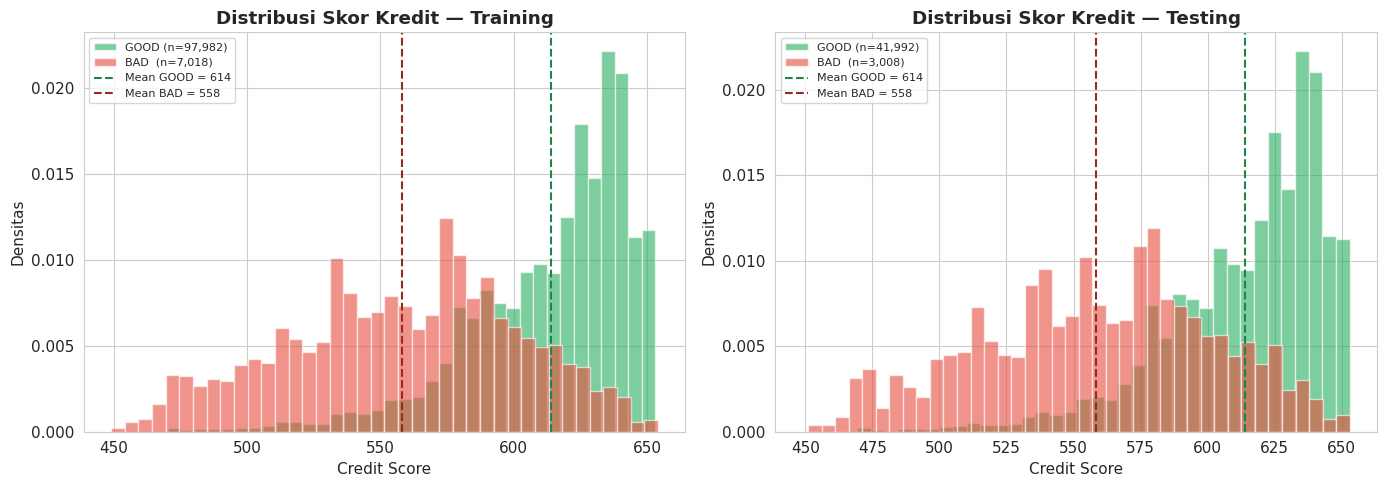

In [102]:
# ── Distribusi Skor: GOOD vs BAD ─────────────────────────────────────────
train_score['target'] = train[target].values
test_score['target']  = test[target].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, score_df) in zip(axes, [('Training', train_score), ('Testing', test_score)]):
    good_scores = score_df[score_df['target'] == 0]['score']
    bad_scores  = score_df[score_df['target'] == 1]['score']

    ax.hist(good_scores, bins=40, alpha=0.6, color='#27ae60',
            label=f'GOOD (n={len(good_scores):,})', density=True)
    ax.hist(bad_scores,  bins=40, alpha=0.6, color='#e74c3c',
            label=f'BAD  (n={len(bad_scores):,})',  density=True)

    ax.axvline(good_scores.mean(), color='#1e8449',
               linestyle='--', linewidth=1.5,
               label=f'Mean GOOD = {good_scores.mean():.0f}')
    ax.axvline(bad_scores.mean(),  color='#922b21',
               linestyle='--', linewidth=1.5,
               label=f'Mean BAD = {bad_scores.mean():.0f}')

    ax.set_title(f'Distribusi Skor Kredit — {label}', fontweight='bold')
    ax.set_xlabel('Credit Score')
    ax.set_ylabel('Densitas')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('05_distribusi_skor.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Tahap 6 — Evaluasi Model

Evaluasi model credit risk **tidak menggunakan accuracy** sebagai metrik utama  
karena data sangat tidak seimbang (~6-7% BAD saja).

### Metrik Standar Industri Perbankan

| Metrik | Rentang Ideal | Keterangan |
|---|---|---|
| **AUC-ROC** | > 0.70 | Kemampuan diskriminasi model |
| **KS Statistic** | > 0.30 | Pemisahan skor GOOD vs BAD |
| **Gini Coefficient** | > 0.40 | = 2×AUC - 1 |


In [103]:
# ── Prediksi Probabilitas ────────────────────────────────────────────────
y_pred_train = lr.predict_proba(X_train)[:, 1]
y_pred_test  = lr.predict_proba(X_test)[:, 1]

# ── AUC-ROC ──────────────────────────────────────────────────────────────
auc_train = roc_auc_score(y_train, y_pred_train)
auc_test  = roc_auc_score(y_test,  y_pred_test)

# ── Gini Coefficient ─────────────────────────────────────────────────────
gini_train = 2 * auc_train - 1
gini_test  = 2 * auc_test  - 1

# ── KS Statistic ──────────────────────────────────────────────────────────
def hitung_ks(y_true, y_prob):
    df_ks = pd.DataFrame({'y_true': y_true, 'y_prob': y_prob})
    df_ks = df_ks.sort_values('y_prob', ascending=False).reset_index(drop=True)
    total_bad  = df_ks['y_true'].sum()
    total_good = len(df_ks) - total_bad
    df_ks['cum_bad']  = df_ks['y_true'].cumsum() / total_bad
    df_ks['cum_good'] = (1 - df_ks['y_true']).cumsum() / total_good
    df_ks['ks']       = abs(df_ks['cum_bad'] - df_ks['cum_good'])
    return df_ks['ks'].max()

ks_train = hitung_ks(y_train.values, y_pred_train)
ks_test  = hitung_ks(y_test.values,  y_pred_test)

print("=" * 55)
print("RINGKASAN PERFORMA MODEL")
print("=" * 55)
print(f"{'Metrik':<25} {'Training':>12} {'Testing':>12}")
print("-" * 55)
print(f"{'AUC-ROC':<25} {auc_train:>12.4f} {auc_test:>12.4f}")
print(f"{'Gini Coefficient':<25} {gini_train:>12.4f} {gini_test:>12.4f}")
print(f"{'KS Statistic':<25} {ks_train:>12.4f} {ks_test:>12.4f}")
print("=" * 55)
print()

def verdict(metric, value, threshold):
    return f"✅ {'BAIK':6}" if value >= threshold else f"⚠️  {'PERLU PENINGKATAN':6}"

print(f"Verdict AUC-ROC (threshold 0.70) : {verdict('auc', auc_test, 0.70)}")
print(f"Verdict Gini    (threshold 0.40) : {verdict('gini', gini_test, 0.40)}")
print(f"Verdict KS      (threshold 0.30) : {verdict('ks', ks_test, 0.30)}")


RINGKASAN PERFORMA MODEL
Metrik                        Training      Testing
-------------------------------------------------------
AUC-ROC                         0.8573       0.8561
Gini Coefficient                0.7147       0.7123
KS Statistic                    0.5576       0.5583

Verdict AUC-ROC (threshold 0.70) : ✅ BAIK  
Verdict Gini    (threshold 0.40) : ✅ BAIK  
Verdict KS      (threshold 0.30) : ✅ BAIK  


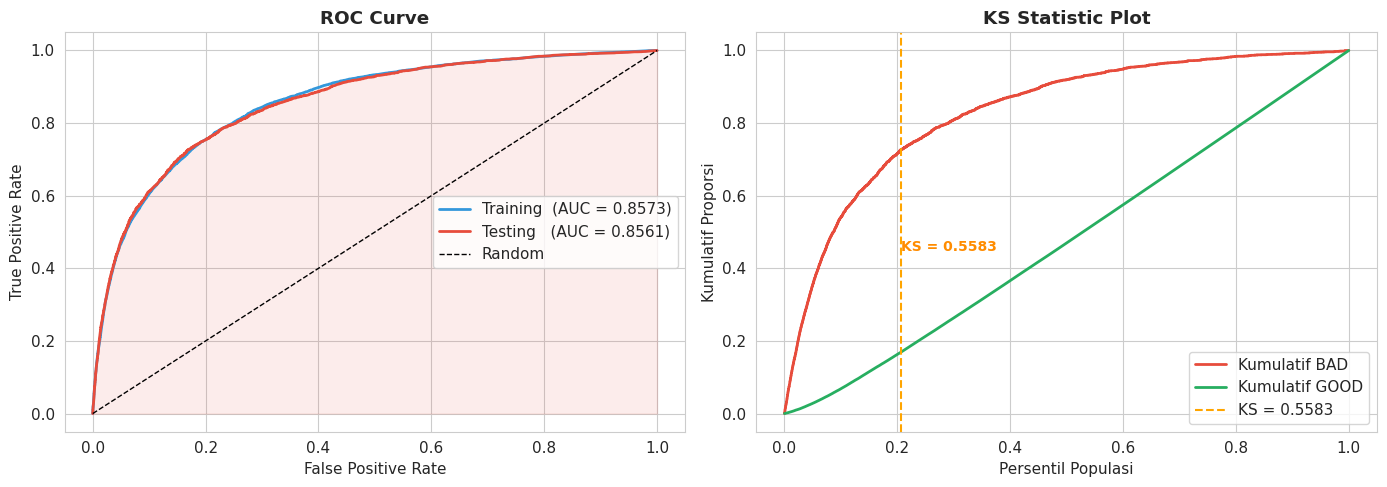

In [104]:
# ── ROC Curve ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr_tr, tpr_tr, _ = roc_curve(y_train, y_pred_train)
fpr_te, tpr_te, _ = roc_curve(y_test,  y_pred_test)

axes[0].plot(fpr_tr, tpr_tr, color='#3498db', lw=2,
             label=f'Training  (AUC = {auc_train:.4f})')
axes[0].plot(fpr_te, tpr_te, color='#e74c3c', lw=2,
             label=f'Testing   (AUC = {auc_test:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].fill_between(fpr_te, tpr_te, alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

# KS Plot (Kolmogorov-Smirnov)
df_ks = pd.DataFrame({'y_true': y_test.values, 'y_prob': y_pred_test})
df_ks = df_ks.sort_values('y_prob', ascending=False).reset_index(drop=True)
df_ks['pct']      = (df_ks.index + 1) / len(df_ks)
total_bad         = df_ks['y_true'].sum()
total_good        = len(df_ks) - total_bad
df_ks['cum_bad']  = df_ks['y_true'].cumsum() / total_bad
df_ks['cum_good'] = (1 - df_ks['y_true']).cumsum() / total_good
df_ks['ks']       = abs(df_ks['cum_bad'] - df_ks['cum_good'])
ks_idx            = df_ks['ks'].idxmax()

axes[1].plot(df_ks['pct'], df_ks['cum_bad'],  color='#e74c3c', lw=2, label='Kumulatif BAD')
axes[1].plot(df_ks['pct'], df_ks['cum_good'], color='#27ae60', lw=2, label='Kumulatif GOOD')
axes[1].axvline(df_ks.loc[ks_idx, 'pct'],    color='orange',  lw=1.5,
                linestyle='--', label=f'KS = {ks_test:.4f}')
axes[1].annotate(f'KS = {ks_test:.4f}',
                 xy=(df_ks.loc[ks_idx, 'pct'],
                     (df_ks.loc[ks_idx, 'cum_bad'] + df_ks.loc[ks_idx, 'cum_good']) / 2),
                 fontsize=10, color='darkorange', fontweight='bold')
axes[1].set_xlabel('Persentil Populasi')
axes[1].set_ylabel('Kumulatif Proporsi')
axes[1].set_title('KS Statistic Plot', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('06_roc_ks.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Tahap 7 — Business Recommendation

Mengubah hasil model menjadi rekomendasi bisnis yang actionable:
1. Analisis distribusi skor vs bad rate per desil
2. Penentuan **cut-off skor** untuk kebijakan kredit
3. Simulasi dampak bisnis dari kebijakan yang diusulkan


In [105]:
# ── Analisis Desil: Skor vs Bad Rate ────────────────────────────────────
df_eval = test_score[['score', 'target']].copy()
df_eval['desil'] = pd.qcut(df_eval['score'], q=10,
                            labels=[f'D{i}' for i in range(10, 0, -1)])

desil_df = (df_eval.groupby('desil', observed=True)
            .agg(
                Jumlah_Nasabah = ('score', 'count'),
                Bad_Count      = ('target', 'sum'),
                Min_Skor       = ('score', 'min'),
                Max_Skor       = ('score', 'max'),
                Rata_Skor      = ('score', 'mean')
            )
            .assign(Bad_Rate = lambda x: (x['Bad_Count'] / x['Jumlah_Nasabah'] * 100).round(2))
            .round({'Rata_Skor': 1, 'Min_Skor': 1, 'Max_Skor': 1})
            .reset_index())

print("=" * 75)
print("ANALISIS DESIL — DISTRIBUSI SKOR & BAD RATE (Testing Set)")
print("=" * 75)
print("D1 = Skor Terendah (Risiko Tertinggi) | D10 = Skor Tertinggi (Risiko Terendah)")
print("-" * 75)
print(desil_df.to_string(index=False))


ANALISIS DESIL — DISTRIBUSI SKOR & BAD RATE (Testing Set)
D1 = Skor Terendah (Risiko Tertinggi) | D10 = Skor Tertinggi (Risiko Terendah)
---------------------------------------------------------------------------
desil  Jumlah_Nasabah  Bad_Count  Min_Skor  Max_Skor  Rata_Skor  Bad_Rate
  D10            4596       1638  449.0000  567.0000   535.7000   35.6400
   D9            4623        543  568.0000  586.0000   578.3000   11.7500
   D8            4313        256  587.0000  598.0000   592.6000    5.9400
   D7            4520        191  599.0000  610.0000   605.0000    4.2300
   D6            4583        141  611.0000  620.0000   615.5000    3.0800
   D5            5042        101  621.0000  627.0000   624.2000    2.0000
   D4            3918         42  628.0000  633.0000   630.5000    1.0700
   D3            4613         48  634.0000  638.0000   635.8000    1.0400
   D2            4375         24  639.0000  643.0000   640.9000    0.5500
   D1            4417         24  644.0000  653

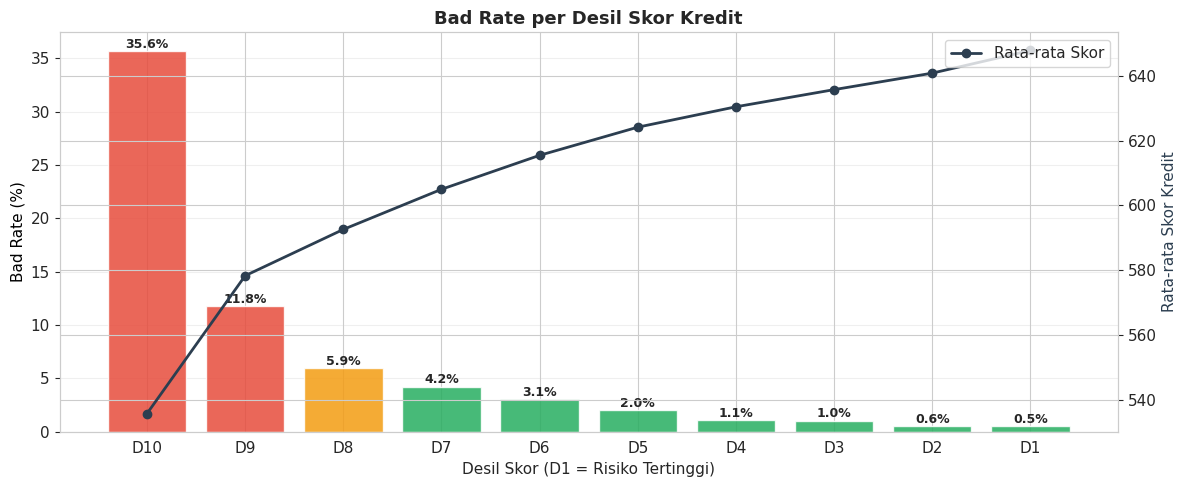

In [106]:
# ── Visualisasi Bad Rate per Desil ────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 5))

color_bars = ['#e74c3c' if r > 10 else '#f39c12' if r > 5 else '#27ae60'
              for r in desil_df['Bad_Rate']]

bars = ax1.bar(desil_df['desil'], desil_df['Bad_Rate'],
               color=color_bars, edgecolor='white', alpha=0.85, zorder=2)
ax1.set_xlabel('Desil Skor (D1 = Risiko Tertinggi)')
ax1.set_ylabel('Bad Rate (%)', color='black')
ax1.set_title('Bad Rate per Desil Skor Kredit', fontweight='bold', fontsize=13)
ax1.grid(axis='y', alpha=0.3, zorder=1)

for bar, val in zip(bars, desil_df['Bad_Rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(desil_df['desil'], desil_df['Rata_Skor'],
         color='#2c3e50', marker='o', linewidth=2, markersize=6,
         label='Rata-rata Skor', zorder=3)
ax2.set_ylabel('Rata-rata Skor Kredit', color='#2c3e50')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('07_badrate_desil.png', dpi=150, bbox_inches='tight')
plt.show()


In [107]:
# ── Penentuan Cut-Off & Segmentasi Risiko ────────────────────────────────
# Hitung cut-off berdasarkan persentil skor pada testing set
p20  = test_score['score'].quantile(0.20)   # 20% terbawah → REJECT
p40  = test_score['score'].quantile(0.40)   # 20-40% → REVIEW MANUAL

cutoff_reject = round(p20, 0)
cutoff_review = round(p40, 0)

print("=" * 65)
print("USULAN KEBIJAKAN CUT-OFF KREDIT")
print("=" * 65)
print(f"  REJECT (Tolak Otomatis) : Skor < {cutoff_reject:.0f}")
print(f"  REVIEW (Review Manual)  : Skor {cutoff_reject:.0f} – {cutoff_review:.0f}")
print(f"  APPROVE (Setujui)       : Skor > {cutoff_review:.0f}")
print()

# Simulasi dampak
def segmentasi(skor):
    if skor < cutoff_reject: return 'REJECT'
    elif skor <= cutoff_review: return 'REVIEW'
    else: return 'APPROVE'

df_eval['Keputusan'] = test_score['score'].apply(segmentasi)

sim = (df_eval.groupby('Keputusan', observed=True)
       .agg(
           Jumlah = ('score', 'count'),
           Bad    = ('target', 'sum')
       )
       .assign(
           Pct_Nasabah = lambda x: (x['Jumlah'] / len(df_eval) * 100).round(1),
           Bad_Rate    = lambda x: (x['Bad'] / x['Jumlah'] * 100).round(2)
       )
       .reindex(['REJECT', 'REVIEW', 'APPROVE'])
       .reset_index())

print("=" * 65)
print("SIMULASI DAMPAK KEBIJAKAN CUT-OFF")
print("=" * 65)
print(sim.to_string(index=False))


USULAN KEBIJAKAN CUT-OFF KREDIT
  REJECT (Tolak Otomatis) : Skor < 586
  REVIEW (Review Manual)  : Skor 586 – 610
  APPROVE (Setujui)       : Skor > 610

SIMULASI DAMPAK KEBIJAKAN CUT-OFF
Keputusan  Jumlah  Bad  Pct_Nasabah  Bad_Rate
   REJECT    8996 2154      20.0000   23.9400
   REVIEW    9056  474      20.1000    5.2300
  APPROVE   26948  380      59.9000    1.4100


In [108]:
# ── Rekomendasi Bisnis Akhir ──────────────────────────────────────────────
approve_data = df_eval[df_eval['Keputusan'] == 'APPROVE']
reject_data  = df_eval[df_eval['Keputusan'] == 'REJECT']
review_data  = df_eval[df_eval['Keputusan'] == 'REVIEW']

print("=" * 65)
print("REKOMENDASI BISNIS")
print("=" * 65)
print()
print(f"1. REJECT otomatis pada skor < {cutoff_reject:.0f}")
print(f"   → {len(reject_data):,} nasabah ({len(reject_data)/len(df_eval)*100:.1f}%) ditolak")
print(f"   → Bad rate segmen ini: {reject_data['target'].mean()*100:.1f}%")
print()
print(f"2. REVIEW manual untuk skor {cutoff_reject:.0f} – {cutoff_review:.0f}")
print(f"   → {len(review_data):,} nasabah ({len(review_data)/len(df_eval)*100:.1f}%) perlu analisis tambahan")
print(f"   → Bad rate segmen ini: {review_data['target'].mean()*100:.1f}%")
print()
print(f"3. APPROVE otomatis pada skor > {cutoff_review:.0f}")
print(f"   → {len(approve_data):,} nasabah ({len(approve_data)/len(df_eval)*100:.1f}%) disetujui")
print(f"   → Bad rate segmen ini: {approve_data['target'].mean()*100:.1f}%")
print()
print("-" * 65)
print("CATATAN:")
print("  • Model menggunakan metrik KS Statistic dan AUC-ROC sebagai")
print("    standar evaluasi industri perbankan.")
print("  • Cut-off dapat disesuaikan dengan risk appetite lembaga.")
print("  • Model perlu di-monitor secara berkala menggunakan PSI")
print("    (Population Stability Index) untuk mendeteksi pergeseran data.")


REKOMENDASI BISNIS

1. REJECT otomatis pada skor < 586
   → 8,996 nasabah (20.0%) ditolak
   → Bad rate segmen ini: 23.9%

2. REVIEW manual untuk skor 586 – 610
   → 9,056 nasabah (20.1%) perlu analisis tambahan
   → Bad rate segmen ini: 5.2%

3. APPROVE otomatis pada skor > 610
   → 26,948 nasabah (59.9%) disetujui
   → Bad rate segmen ini: 1.4%

-----------------------------------------------------------------
CATATAN:
  • Model menggunakan metrik KS Statistic dan AUC-ROC sebagai
    standar evaluasi industri perbankan.
  • Cut-off dapat disesuaikan dengan risk appetite lembaga.
  • Model perlu di-monitor secara berkala menggunakan PSI
    (Population Stability Index) untuk mendeteksi pergeseran data.


---
## ✅ Kesimpulan Proyek

| Komponen | Detail |
|---|---|
| **Dataset** | Give Me Some Credit (Kaggle) — 150.000 nasabah |
| **Metode** | WoE + Information Value + Logistic Regression |
| **Output Utama** | Credit Scorecard (poin per variabel per bin) |
| **Metrik Evaluasi** | AUC-ROC, Gini Coefficient, KS Statistic |
| **Rekomendasi** | Cut-off skor dengan 3 segmen: Reject / Review / Approve |

### Pembelajaran Kunci
1. **WoE/IV** adalah teknik pra-pemrosesan standar industri yang lebih baik dari encoding biasa
2. **Logistic Regression** dipilih karena explainability untuk kebutuhan audit regulasi
3. **KS Statistic** dan **Gini** lebih relevan dari accuracy untuk credit risk
4. **Cut-off** harus disesuaikan dengan risk appetite bisnis, bukan hanya optimasi matematis

---
*Proyek ini merupakan implementasi mandiri metodologi credit scoring berbasis industri perbankan.*  
*Referensi: Siddiqi, N. (2006). Credit Risk Scorecards. Wiley.*
